In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv("./datasets/null.csv")

In [3]:
df.head()

,ID,Name,Age,Salary,Department
0,1,John,28.0,50000.0,IT
1,2,Mary,32.0,NaN,HR
2,3,Bob,45.0,70000.0,Finance
3,4,Alice,29.0,55000.0,IT
4,5,Tom,35.0,60000.0,HR


In [4]:
df.isnull().head()    #gives a dataset having True when the value is null else false

,ID,Name,Age,Salary,Department
0,False,False,False,False,False
1,False,False,False,True,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False


In [5]:
df.isnull().mean()*100

ID             0.0
Name           0.0
Age           10.0
Salary         5.0
Department     0.0
dtype: float64

# 1 Remove the rows or column containing the null variable
    - Only remove the rows if the null value data is completely at random
    - After removing the data, it shouldnt disturb the distribution of dataset(can be checked through histplot)
    - Only remove the null value is less than or equal to 5% of total data

In [6]:
column= [x for x in df.columns if df[x].isnull().mean()*100 <= 5 and df[x].isnull().mean()*100>0]
column

['Salary']

In [7]:
new_df= df.dropna(subset= ['Salary'])

In [8]:
df.shape

(20, 5)

In [9]:
new_df.shape

(19, 5)

In [10]:
df.isnull().sum()

ID            0
Name          0
Age           2
Salary        1
Department    0
dtype: int64

In [11]:
new_df.isnull().sum()

ID            0
Name          0
Age           2
Salary        0
Department    0
dtype: int64

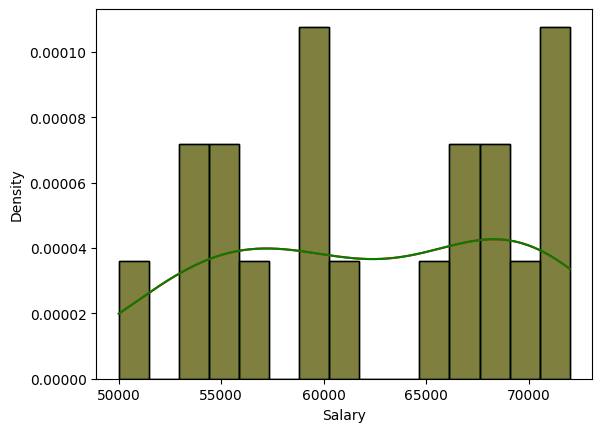

In [12]:
# to check the disribution
import seaborn as sns
import matplotlib.pyplot as plt



sns.histplot(df['Salary'], color= 'red', stat= 'density', bins= 15, kde= True)
sns.histplot(new_df['Salary'], color= 'green', stat='density', bins= 15, kde= True)    #if both are same then we can say their distribution didnt change

plt.show()

In [13]:
len(new_df)/len(df) * 100    #len gives no of rows in dataframe

95.0

<Axes: >

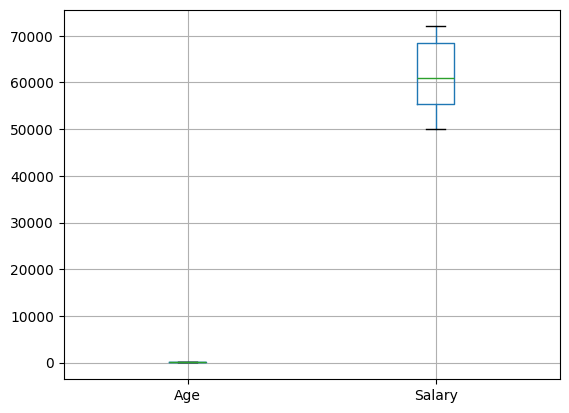

In [14]:
df[['Age', 'Salary']].boxplot()

<Axes: >

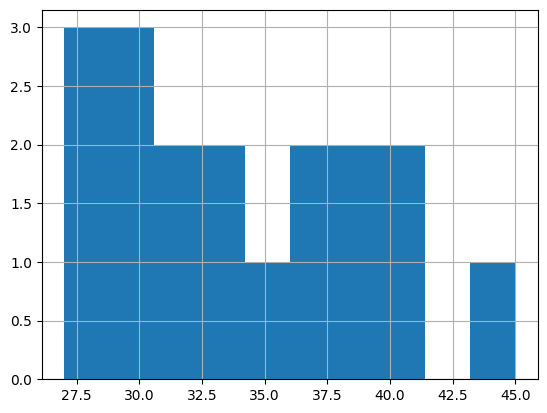

In [15]:
df['Age'].hist()

## Random Value(can be done only using pandas)
    - can be used both for categorical and numerical

In [16]:
df= pd.read_csv('./datasets/train.csv', usecols= ['Age', 'Survived', 'Fare'])

In [17]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [19]:
df['Age'].sample(5)

656     NaN
795    39.0
783     NaN
21     34.0
195    58.0
Name: Age, dtype: float64

In [21]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [22]:
df['Age_without_null']= df['Age']

In [23]:
df.head()

,Survived,Age,Fare,Age_without_null
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [27]:
## REplacing NA by random values where in age_without_null
df.loc[df['Age_without_null'].isnull(), 'Age_without_null']= df.dropna(subset= 'Age_without_null')['Age_without_null'].sample(df['Age_without_null'].isnull().sum()).values

In [28]:
df.isnull().sum()

Survived              0
Age                 177
Fare                  0
Age_without_null      0
dtype: int64

In [31]:
df['Age']> 5

0       True
1       True
2       True
3       True
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: Age, Length: 891, dtype: bool

In [32]:
df

,Survived,Age,Fare,Age_without_null
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0
...,...,...,...,...
886,0,27.0,13.0000,27.0
887,1,19.0,30.0000,19.0
888,0,NaN,23.4500,51.0
889,1,26.0,30.0000,26.0


C:\Users\Yunish\AppData\Local\Temp\ipykernel_19604\4205809213.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


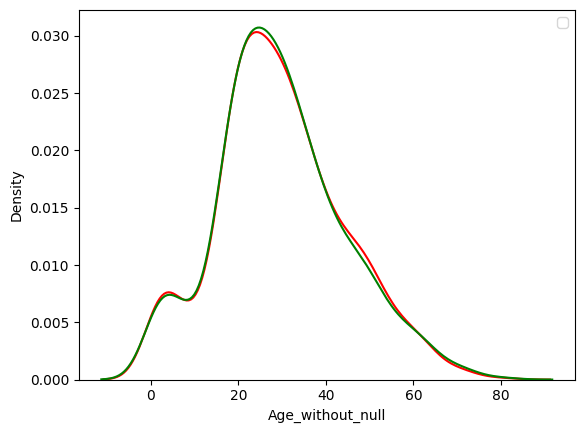

In [55]:
import seaborn as sns
import matplotlib.pyplot as  plt

#plt.figure(figsize= (14, 4))

sns.kdeplot(df['Age_without_null'], color= 'red')

sns.kdeplot(df['Age'], color= 'green')
plt.legend()

plt.show()



In [58]:
df.cov()

,Survived,Age,Fare,Age_without_null
Survived,0.236772,-0.551296,6.221787,-0.370373
Age,-0.551296,211.019125,73.849030,211.019125
Fare,6.221787,73.849030,2469.436846,58.637361
Age_without_null,-0.370373,211.019125,58.637361,210.853722


## for categorical data

In [60]:
df= pd.read_csv("./datasets/train.csv")




In [61]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df= df.iloc[:, [10, 1, 4]]

In [65]:
df.head()

,Cabin,Survived,Sex
0,NaN,0,male
1,C85,1,female
2,NaN,1,female
3,C123,1,female
4,NaN,0,male


In [66]:
df['Cabin_without_null']= df['Cabin']

In [74]:
df.loc[df["Cabin_without_null"].isnull(), 'Cabin_without_null']= df.dropna(subset= ['Cabin_without_null'])['Cabin_without_null'].sample(df['Cabin_without_null'].isnull().sum(), replace= True).values

In [69]:
df['Cabin_without_null'].isnull().sum()

np.int64(687)

In [77]:
df.sample(5)

,Cabin,Survived,Sex,Cabin_without_null
666,NaN,0,male,G6
296,NaN,0,male,E101
259,NaN,1,female,G6
472,NaN,1,female,B96 B98
110,C110,0,male,C110


In [79]:
df.isnull().sum()

Cabin                 687
Survived                0
Sex                     0
Cabin_without_null      0
dtype: int64

## Missing Indicator

In [84]:
from sklearn.impute import MissingIndicator

mi= MissingIndicator()   # makes new column for each column which has null values and and in that column there will be False if there is no null value prior to its original column and places True if there is null value in that new column

df= pd.read_csv("./datasets/train.csv", usecols= ['Age', 'Cabin', 'Survived'])

In [85]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= ['Survived']), df['Survived'], train_size= 0.8)

In [86]:
x_train

,Age,Cabin
776,NaN,F38
188,40.0,NaN
126,NaN,NaN
847,35.0,NaN
23,28.0,A6
...,...,...
209,40.0,A31
274,NaN,NaN
315,26.0,NaN
355,28.0,NaN


In [89]:
x_train_imputed= mi.fit_transform(x_train)
x_test_imputed= mi.transform(x_test)

In [90]:
mi.get_feature_names_out()

array(['missingindicator_Age', 'missingindicator_Cabin'], dtype=object)

In [91]:
pd.DataFrame(x_train_imputed, columns= mi.get_feature_names_out())

,missingindicator_Age,missingindicator_Cabin
0,True,False
1,False,True
2,True,True
3,False,True
4,False,False
...,...,...
707,False,False
708,True,True
709,False,True
710,False,True


We also can use add_indicator inside the Simple Imputer so that it automatically add indicator like this and fill the null at the same time. So this Simple Imputer method is preffered than the one I did in above